In [1]:
# [제공 코드] 이 단원에 필요한 라이브러리와 한국어 토크나이저를 준비합니다.
import json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import chromadb

sns.set_theme(style='whitegrid')
import platform

# 한글 폰트 — 실행 중인 OS 에 맞춰 자동 설정
if platform.system() == 'Windows':
    KOREAN_FONT = 'Malgun Gothic'
    FONT_PATH = 'C:/Windows/Fonts/malgun.ttf'
elif platform.system() == 'Darwin':          # macOS
    KOREAN_FONT = 'AppleGothic'
    FONT_PATH = '/System/Library/Fonts/Supplemental/AppleGothic.ttf'
else:                                        # Linux (Colab 등)
    KOREAN_FONT = 'NanumGothic'
    FONT_PATH = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

plt.rcParams['font.family'] = KOREAN_FONT
plt.rcParams['axes.unicode_minus'] = False   # 마이너스(−) 부호 깨짐 방지

from dotenv import load_dotenv

load_dotenv(".env")       # 같은 폴더의 .env
load_dotenv("../.env")    # 정답 폴더에서 실행하는 경우

# 키를 먼저 확인합니다. 모델을 만든 뒤에 검사하면 인증 오류가 먼저 나서 이 안내가 묻힙니다.
if not os.getenv("OPENAI_API_KEY"):
    raise RuntimeError(
        "이 노트북은 실제 OpenAI 호출이 필요합니다 - OPENAI_API_KEY 를 찾지 못했습니다.\n"
        "  1) 일차 폴더에서  cp .env.example .env\n"
        "  2) .env 를 열어 본인 키를 채우세요\n"
        "  3) 커널을 재시작한 뒤 이 셀부터 다시 실행하세요")

print("OpenAI 키 확인 완료 - 이제 LangChain 으로 모델을 만들 수 있습니다.")

c:\Users\Playdata\OneDrive\Desktop\프로젝트1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


OpenAI 키 확인 완료 - 이제 LangChain 으로 모델을 만들 수 있습니다.


In [2]:
from langchain_openai import ChatOpenAI

# temperature=0 : 같은 질문에 되도록 일정한 답을 받는 설정(수업·채점용).
model = ChatOpenAI(model='gpt-4o-mini', temperature=0)

In [3]:
from sentence_transformers import SentenceTransformer

emb_model = SentenceTransformer(
    "SamilPwC-AXNode-GenAI/PwC-Embedding_expr"
)


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 8798.28it/s]


In [4]:
books=pd.read_csv('./정제데이터/books.csv')


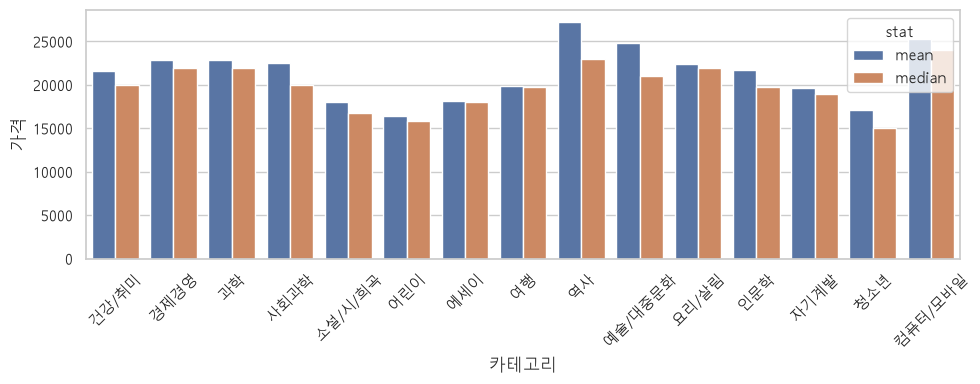

In [19]:
summary = (
    books.groupby("category_name")["priceStandard"]
    .agg(mean="mean", median="median")
    .reset_index()
    .melt(
        id_vars="category_name",
        var_name="stat",
        value_name="priceStandard"
    )
)

fig, ax = plt.subplots(figsize=(10, 4))

sns.barplot(
    data=summary,
    x="category_name",
    y="priceStandard",
    hue="stat",
    errorbar=None,
    ax=ax
)

ax.set_xlabel("카테고리")
ax.set_ylabel("가격")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
import plotly.express as px

summary = (
    books.groupby("category_name")["priceStandard"]
    .agg(mean="mean", median="median")
    .reset_index()
    .melt(
        id_vars="category_name",
        var_name="stat",
        value_name="priceStandard"
    )
)

fig = px.bar(
    summary,
    x="category_name",
    y="priceStandard",
    color="stat",
    barmode="group",
    labels={
        "category_name": "카테고리",
        "priceStandard": "가격",
        "stat": "통계값"
    },
    title="카테고리별 평균·중앙 가격"
)

fig.update_layout(xaxis_tickangle=-45)
fig.show()

In [ ]:
count=books['author'].value_counts()[:10]

author
호메로스                                      27
유시민                                       14
이정기, 타블라라사 편집부                            13
김종원                                       12
히가시노 게이고                                  11
일본보그사                                     10
유홍준                                        9
칼 세이건                                      9
김진우, 박종우, 장용익, 이인섭, 맹형규, 정재일, 한지우, 유태용     8
이꽃님                                        8
Name: count, dtype: int64

In [56]:
count=books['author'].value_counts()[:10].reset_index()
count = count.iloc[::-1]
count['author'].replace('김진우, 박종우, 장용익, 이인섭, 맹형규, 정재일, 한지우, 유태용','김진우 외 7명')

# px.bar(count,x='count',y='author')

9               이꽃님
8          김진우 외 7명
7             칼 세이건
6               유홍준
5             일본보그사
4          히가시노 게이고
3               김종원
2    이정기, 타블라라사 편집부
1               유시민
0              호메로스
Name: author, dtype: object

In [67]:
desc=books['description'].tolist()
embed=emb_model.encode(desc,normalize_embeddings=True)

In [ ]:

books = books.reset_index(names="ids")
books.columns

Index(['ids', 'Unnamed: 0', 'category_name', 'rank_in_category', 'itemId',
       'title', 'author', 'publisher', 'pubDate', 'priceSales',
       'priceStandard', 'salesPoint', 'customerReviewRank', 'link', 'cover',
       'description'],
      dtype='object')

In [4]:
client=chromadb.PersistentClient(path='./chroma_db') #폴더 없으면 자동 생성

#2) 컬렉션 생성
books_col=client.get_or_create_collection(
    name='book',
    metadata={'hnsw:space':'cosine'}
)
#3)데이터 적재
#메타데이터 더 쉽게 생성
META_COLS = [
    "title",
    "category_name",
    "itemId",
    "author",
    "priceStandard",
    "pubDate",
    "publisher",
    "customerReviewRank",
]

meta_dict = books[META_COLS].to_dict("records")

ids = books["ids"].astype(str).tolist()
documents = books["description"].fillna("").astype(str).tolist()

books_col.add(
    ids=ids,
    embeddings=embed,
    documents=documents,
    metadatas=meta_dict
)


KeyError: 'ids'

In [5]:
import chromadb
from sentence_transformers import SentenceTransformer

client = chromadb.PersistentClient(
    path="./chroma_db"
)

print([col.name for col in client.list_collections()])

books_col = client.get_collection(
    name="book"  # 저장할 때 사용한 실제 컬렉션 이름
)

['book']


In [12]:
query='무섭고 살인사건이 나오는 책'
query_emb = emb_model.encode([query], normalize_embeddings=True)

res = books_col.query(query_embeddings=query_emb, n_results=3) #n_results :검색개수 top k개
res 
del books_col
del client

In [84]:
import csv
books1=books.copy()
books1['embed']=[json.dumps(embedding.tolist()) for embedding in embed]
books1.to_csv('./정제데이터/임베딩추가.csv')

In [8]:
query='무섭고 살인사건이 나오는 책'
query_emb = emb_model.encode([query], normalize_embeddings=True)



book_retriever=books_col.query(query_emb,n_results=3)


book_retriever

del books_col
del client

